In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 80, 3, padding=1, groups=20),
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 80, 1),   # pointwise conv
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 60, 3, padding=1, groups=20),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model29_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model29_0)
describe(model29_0)

MACs: 4.92 MMac, Params: 38.29 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1580, Train accuracy = 0.5780, Test loss = 1.1395, Test accuracy = 0.5898
Epoch 2/60: Train loss = 1.0184, Train accuracy = 0.6358, Test loss = 0.9994, Test accuracy = 0.6486
Epoch 3/60: Train loss = 0.8914, Train accuracy = 0.6841, Test loss = 0.8907, Test accuracy = 0.6982
Epoch 4/60: Train loss = 0.8423, Train accuracy = 0.7081, Test loss = 0.8380, Test accuracy = 0.7065
Epoch 5/60: Train loss = 0.6925, Train accuracy = 0.7549, Test loss = 0.6908, Test accuracy = 0.7583
Epoch 6/60: Train loss = 0.7742, Train accuracy = 0.7326, Test loss = 0.7658, Test accuracy = 0.7384
Epoch 7/60: Train loss = 0.6568, Train accuracy = 0.7750, Test loss = 0.6798, Test accuracy = 0.7688
Epoch 8/60: Train loss = 0.5946, Train accuracy = 0.7923, Test loss = 0.6189, Test accuracy = 0.7947
Epoch 9/60: Train loss = 0.6579, Train accuracy = 0.7759, Test loss = 0.6908, Test accuracy = 0.7753
Epoch 10/60: Train loss = 0.6824, Train accuracy = 0.7674, Test loss = 0.7183, Test accurac

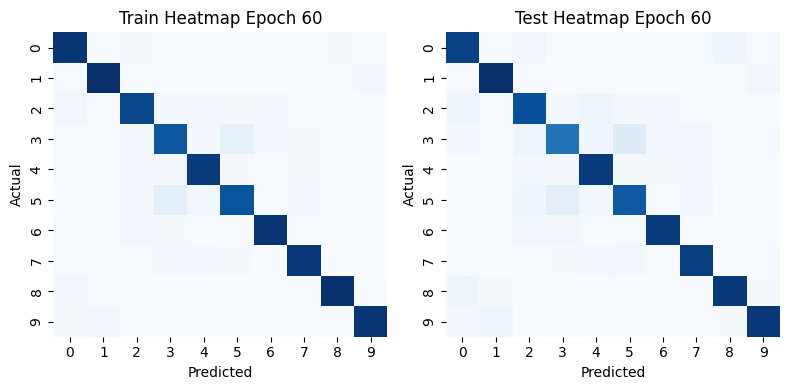

<Figure size 1200x600 with 0 Axes>

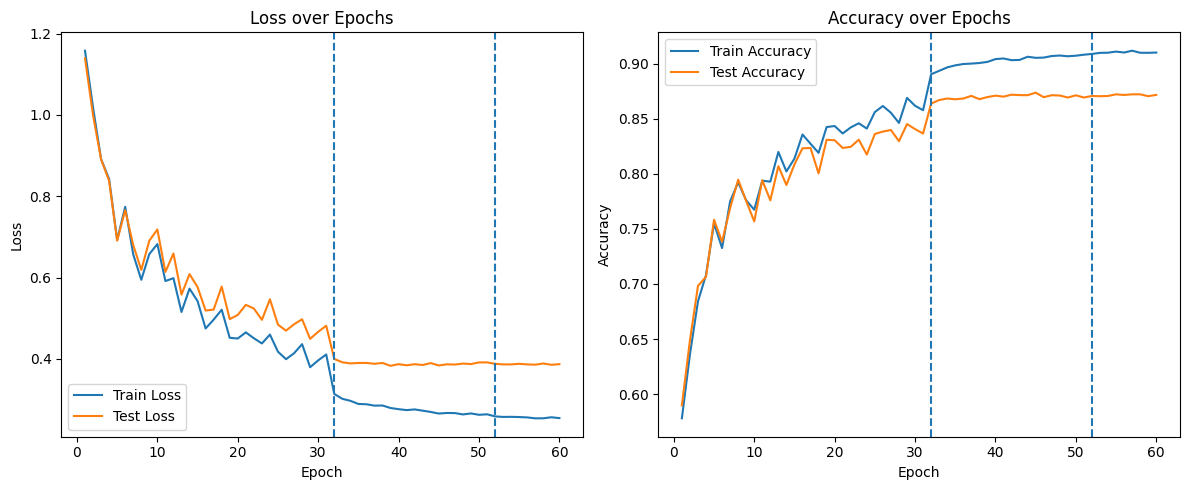

In [6]:
trainf32(model29_0,"model_weights/model29_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model29_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model29_1)
describe(model29_1)

MACs: 4.92 MMac, Params: 38.29 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.0308, Train accuracy = 0.6289, Test loss = 0.9863, Test accuracy = 0.6557
Epoch 2/60: Train loss = 0.8172, Train accuracy = 0.7135, Test loss = 0.8393, Test accuracy = 0.7100
Epoch 3/60: Train loss = 0.7420, Train accuracy = 0.7432, Test loss = 0.7518, Test accuracy = 0.7408
Epoch 4/60: Train loss = 0.6791, Train accuracy = 0.7601, Test loss = 0.7098, Test accuracy = 0.7560
Epoch 5/60: Train loss = 0.7166, Train accuracy = 0.7536, Test loss = 0.7584, Test accuracy = 0.7483
Epoch 6/60: Train loss = 0.6108, Train accuracy = 0.7853, Test loss = 0.6274, Test accuracy = 0.7820
Epoch 7/60: Train loss = 0.6238, Train accuracy = 0.7847, Test loss = 0.6675, Test accuracy = 0.7736
Epoch 8/60: Train loss = 0.5725, Train accuracy = 0.7996, Test loss = 0.5986, Test accuracy = 0.7980
Epoch 9/60: Train loss = 0.5612, Train accuracy = 0.8061, Test loss = 0.6149, Test accuracy = 0.7863
Epoch 10/60: Train loss = 0.5380, Train accuracy = 0.8131, Test loss = 0.5720, Test accurac

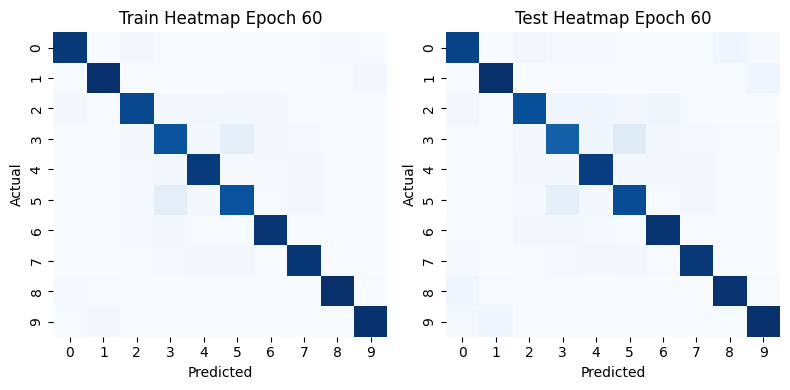

<Figure size 1200x600 with 0 Axes>

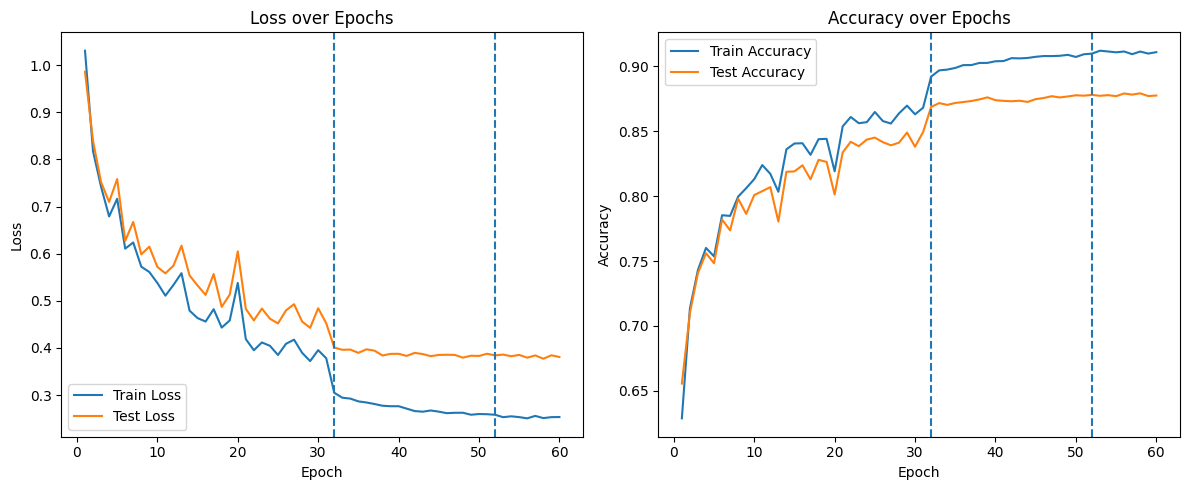

In [8]:
trainf32(model29_1,"model_weights/model29_1.pt",criterion,train_dataset,val_dataset, batch_size=64)